# Experiment 2: frontier-shaped dual-scale MiniGrid CNN-DQN

This notebook fine-tunes the completed 2,000-episode novelty-only model. It preserves the dual-scale architecture, starts a fresh replay buffer, and adds known-space BFS frontier shaping plus a small blocked-forward penalty. Experiment 1 remains unchanged at `models/minigrid_dual_scale_explorer.pth`; all new checkpoints and diagnostics go under `experiment_2/`.


## Imports and configuration

In [25]:
from collections import Counter
from copy import deepcopy
from pathlib import Path

import gymnasium as gym
import numpy as np
import torch
import torch.optim as optim

from minigrid.core.constants import OBJECT_TO_IDX

from utils import alert_training_complete
from utils.dqn_utils import hard_update_target, linear_epsilon, set_seed
from utils.minigrid_dual_scale_dqn import (
    DualScaleMapDQN,
    DualScaleReplayBuffer,
    EXPLORATION_ACTIONS,
    dual_scale_dqn_train_step,
    load_dual_scale_checkpoint,
    make_dual_scale_state,
    mask_q_values,
    save_dual_scale_checkpoint,
    select_masked_epsilon_greedy_action,
    select_masked_greedy_action,
)
from utils.minigrid_map_encoder import PersistentMapTensorEncoder
from utils.minigrid_mapper import MapCell, PersistentMiniGridMapper
from utils.notebook_display import display_channel_grid
from utils.procedural_rooms_env import ENVIRONMENT_ID
from utils.minigrid_experiment2 import (
    DEFAULT_COVERAGE_THRESHOLDS,
    ExplorationRewardConfig,
    compute_exploration_reward,
    evaluate_exploration_controller,
    load_experiment_policy,
    reachable_frontier_distance,
    run_experiment_2,
    save_comparison_artifacts,
    summarize_evaluations,
)


In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Tensor and network configuration
local_size = 15
global_size = 15
unknown_padding = 2
hysteresis_bins = 1
conv_channels = (32, 64, 64)
fusion_hidden_size = 256

# Procedural training distribution
training_environment_config = {
    "width": 19,
    "height": 19,
    "min_rooms": 4,
    "max_rooms": 6,
    "min_room_size": 5,
    "doorway_width": 1,
    "max_steps": 400,
}

# Disjoint procedural seed ranges
training_seed_start = 0
training_seed_count = 10_000
validation_seeds = list(range(20_000, 20_100))
test_seeds = list(range(30_000, 30_200))
generalization_seeds = list(range(40_000, 40_100))

# Long training is intentionally opt-in after visual validation.
RUN_EXPERIMENT_2 = True
RUN_MATCHED_EVALUATION = True

Device: cuda


## Visual validation of local and global tensors

The mapper is allowed to accumulate knowledge through random exploration actions. Hidden map state is not used. The displayed tensors are exactly what the CNN receives.

Global scale: 2
Known map bounds: (np.int64(-7), np.int64(4), np.int64(-6), np.int64(9))
Agent position: (np.int64(1), np.int64(3))
Agent direction: 2
Local tensor shape: (4, 15, 15)
Global tensor shape: (5, 15, 15)
Local channels: free, wall, unknown, frontier


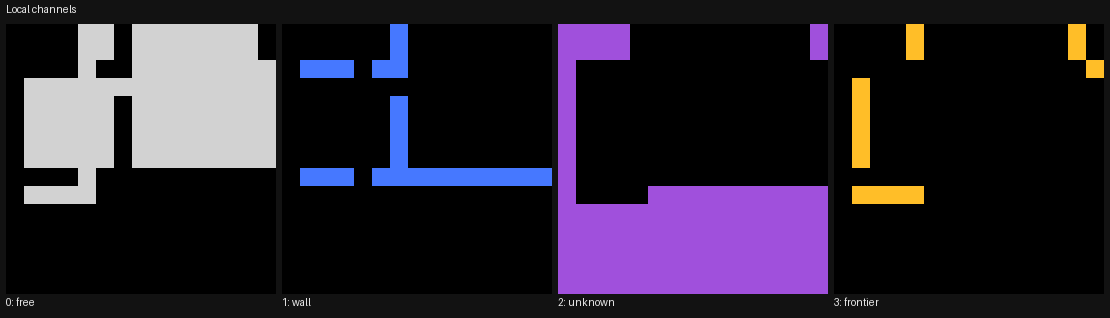

Global channels: known_density, free_density, wall_density, frontier_density, agent


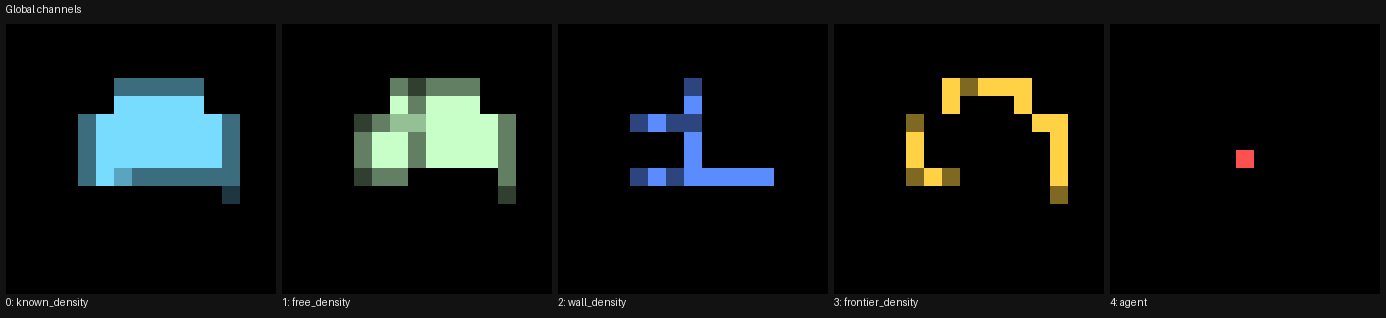

In [27]:
visual_env = gym.make(ENVIRONMENT_ID, max_steps=120)
observation, info = visual_env.reset(seed=1234)
visual_env.action_space.seed(1234)
visual_mapper = PersistentMiniGridMapper()
visual_mapper.reset(observation)
visual_encoder = PersistentMapTensorEncoder(
    local_size=local_size,
    global_size=global_size,
    unknown_padding=unknown_padding,
    hysteresis_bins=hysteresis_bins,
)
visual_encoder.reset()

for _ in range(100):
    action = visual_env.action_space.sample() % 3
    visual_mapper.predict_action(action)
    observation, reward, terminated, truncated, info = visual_env.step(
        action
    )
    visual_mapper.observe(observation)

    if terminated or truncated:
        break

encoded_visual_map = visual_encoder.encode(visual_mapper)
visual_env.close()

print("Global scale:", encoded_visual_map.global_scale)
print("Known map bounds:", visual_mapper.known_bounds(padding=0))
print("Agent position:", tuple(visual_mapper.position))
print("Agent direction:", visual_mapper.direction)
print("Local tensor shape:", encoded_visual_map.local.shape)
print("Global tensor shape:", encoded_visual_map.global_map.shape)

print("Local channels:", ", ".join(visual_encoder.LOCAL_CHANNELS))
display_channel_grid(
    encoded_visual_map.local,
    visual_encoder.LOCAL_CHANNELS,
    columns=4,
    title="Local channels",
)
print("Global channels:", ", ".join(visual_encoder.GLOBAL_CHANNELS))
display_channel_grid(
    encoded_visual_map.global_map,
    visual_encoder.GLOBAL_CHANNELS,
    columns=5,
    title="Global channels",
)

## Orientation normalization

The same persistent world map is encoded under all four compass directions. The geometry rotates so tensor-up is always forward, while the agent remains fixed at the center.

Direction order: east, south, west, north
Shown channel: local wall occupancy; tensor-up is forward.


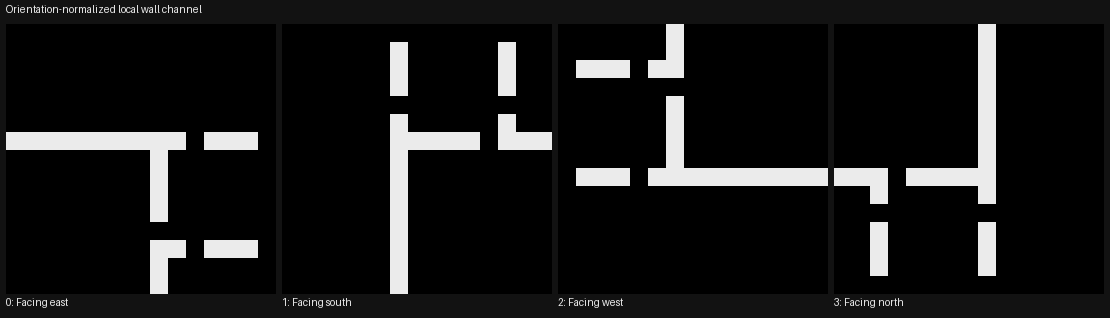

In [28]:
direction_names = ("east", "south", "west", "north")
rotated_channels = []

for direction in range(4):
    rotated_mapper = deepcopy(visual_mapper)
    rotated_mapper.direction = direction
    rotated_encoder = PersistentMapTensorEncoder(
        local_size=local_size, global_size=global_size
    )
    rotated = rotated_encoder.encode(rotated_mapper)
    rotated_channels.append(rotated.local[1])

print("Direction order:", ", ".join(direction_names))
print("Shown channel: local wall occupancy; tensor-up is forward.")
display_channel_grid(
    rotated_channels,
    [f"Facing {name}" for name in direction_names],
    columns=4,
    title="Orientation-normalized local wall channel",
)

## Targeted adaptive-scale and hysteresis tests

In [29]:
class SyntheticMapper:
    """Minimal mapper interface for deterministic encoder tests."""

    def __init__(self):
        self.position = np.array([0, 0], dtype=int)
        self.direction = 0
        self.cells = {}

    def frontier_cells(self):
        return set()


empty_cell = MapCell(
    object_idx=OBJECT_TO_IDX["empty"], color_idx=0, state=0
)
synthetic_mapper = SyntheticMapper()
scale_encoder = PersistentMapTensorEncoder(
    global_size=15, unknown_padding=2, hysteresis_bins=1
)

scale_cases = [
    ("comfortably fits", 4, 1),
    ("approaches boundary", 5, 1),
    ("padding barely exceeds nominal radius", 6, 1),
    ("requires scale 2", 7, 2),
    ("requires scale 4", 15, 4),
]
observed_scales = []

for label, extent, expected_scale in scale_cases:
    synthetic_mapper.cells = {
        (x, 0): empty_cell for x in range(-extent, extent + 1)
    }
    encoded = scale_encoder.encode(synthetic_mapper)
    observed_scales.append(encoded.global_scale)
    assert encoded.global_scale == expected_scale, label
    print(f"{label:40s} extent={extent:2d} scale={encoded.global_scale}")

# Shrinking the known map cannot reduce scale within the episode.
synthetic_mapper.cells = {(0, 0): empty_cell}
assert scale_encoder.encode(synthetic_mapper).global_scale == 4

# A new episode explicitly resets scale to exact resolution.
scale_encoder.reset()
small_encoding = scale_encoder.encode(synthetic_mapper)
assert small_encoding.global_scale == 1
assert np.all((small_encoding.global_map[:4] == 0) | (small_encoding.global_map[:4] == 1))

print("Scale sequence:", observed_scales)
print("No oscillation and scale-1 binary-density checks passed.")

comfortably fits                         extent= 4 scale=1
approaches boundary                      extent= 5 scale=1
padding barely exceeds nominal radius    extent= 6 scale=1
requires scale 2                         extent= 7 scale=2
requires scale 4                         extent=15 scale=4
Scale sequence: [1, 1, 1, 2, 4]
No oscillation and scale-1 binary-density checks passed.


## CNN forward, masking, and gradient tests

In [30]:
test_network = DualScaleMapDQN(
    action_dim=7,
    conv_channels=conv_channels,
    fusion_hidden_size=fusion_hidden_size,
).to(device)

for test_batch_size in (1, 32, 64):
    local_batch = torch.rand(test_batch_size, 4, 15, 15, device=device)
    global_batch = torch.rand(test_batch_size, 5, 15, 15, device=device)
    scale_batch = torch.randint(
        0, 4, (test_batch_size, 1), device=device
    ).float()
    q_values = test_network(local_batch, global_batch, scale_batch)

    assert q_values.shape == (test_batch_size, 7)
    assert torch.all(torch.isfinite(q_values))
    assert torch.all(
        torch.isneginf(mask_q_values(q_values)[:, 3:])
    )

test_network.zero_grad()
q_values.sum().backward()
gradient_groups = {
    "local CNN": list(test_network.local_cnn.parameters()),
    "global CNN": list(test_network.global_cnn.parameters()),
    "fusion": list(test_network.fusion.parameters()),
    "DQN head": list(test_network.dqn_head.parameters()),
}

for group_name, parameters in gradient_groups.items():
    assert all(parameter.grad is not None for parameter in parameters)
    assert all(torch.all(torch.isfinite(parameter.grad)) for parameter in parameters)
    print(group_name, "gradients: OK")

print("Batch sizes 1, 32, and 64 produced finite (B, 7) outputs.")

local CNN gradients: OK
global CNN gradients: OK
fusion gradients: OK
DQN head gradients: OK
Batch sizes 1, 32, and 64 produced finite (B, 7) outputs.


## Experiment 2 reward and evaluation helpers

Frontier distance is computed by exact BFS through mapper-known traversable cells only. Discovery transitions use novelty reward alone, so moving the frontier outward cannot punish successful exploration. Threshold metrics always pair success fraction with time conditional on success.


In [31]:
coverage_thresholds = DEFAULT_COVERAGE_THRESHOLDS
tensor_config = {
    "local_size": local_size,
    "global_size": global_size,
    "unknown_padding": unknown_padding,
    "hysteresis_bins": hysteresis_bins,
}
reward_config = ExplorationRewardConfig(
    exploration_beta=1.0,
    frontier_progress_beta=0.15,
    blocked_penalty=-0.02,
)

print("Reward configuration:", reward_config)
print("Frontier shaping uses mapper-known BFS only; validation is greedy (epsilon=0).")


Reward configuration: ExplorationRewardConfig(exploration_beta=1.0, frontier_progress_beta=0.15, blocked_penalty=-0.02)
Frontier shaping uses mapper-known BFS only; validation is greedy (epsilon=0).


## Experiment 2 fine-tuning

The Experiment 1 CNN weights are loaded into the policy, copied into the target network, and fine-tuned with a new optimizer and an empty replay buffer. Set `RUN_EXPERIMENT_2 = True` only when ready for the long run. Every validation checkpoint saves the full training state and three fixed-seed greedy trajectory bundles.


In [32]:
num_fine_tuning_episodes = 2_000
gamma = 0.99
learning_rate = 5e-5
batch_size = 64
replay_capacity = 100_000
minimum_replay_size = 5_000
target_update_frequency = 1_000
gradient_clip = 10.0
epsilon_start = 0.25
epsilon_end = 0.05
epsilon_decay_steps = 200_000
validation_frequency = 100
validation_subset = validation_seeds[:20]
diagnostic_validation_seeds = [
    validation_seeds[0],
    validation_seeds[len(validation_seeds) // 2],
    validation_seeds[-1],
]
training_random_seed = 43

experiment_1_model_path = Path("models") / "minigrid_dual_scale_explorer.pth"
experiment_2_output_dir = Path("experiment_2")
experiment_2_model_path = experiment_2_output_dir / "final_model.pth"

if not experiment_1_model_path.exists():
    raise FileNotFoundError(
        f"Experiment 1 checkpoint not found: {experiment_1_model_path.resolve()}"
    )
print("Experiment 1 checkpoint:", experiment_1_model_path.resolve())
print("Experiment 2 output:", experiment_2_output_dir.resolve())


Experiment 1 checkpoint: C:\Users\Lenovo\Documents\GitHub\Mobile-Robotics\models\minigrid_dual_scale_explorer.pth
Experiment 2 output: C:\Users\Lenovo\Documents\GitHub\Mobile-Robotics\experiment_2


In [33]:
if RUN_EXPERIMENT_2:
    policy_net, experiment_2_checkpoint = run_experiment_2(
        pretrained_checkpoint=experiment_1_model_path,
        output_dir=experiment_2_output_dir,
        environment_config=training_environment_config,
        tensor_config=tensor_config,
        validation_seeds=validation_subset,
        diagnostic_validation_seeds=diagnostic_validation_seeds,
        device=device,
        reward_config=reward_config,
        num_training_episodes=num_fine_tuning_episodes,
        training_seed_start=training_seed_start,
        training_seed_count=training_seed_count,
        training_random_seed=training_random_seed,
        learning_rate=learning_rate,
        gamma=gamma,
        batch_size=batch_size,
        replay_capacity=replay_capacity,
        minimum_replay_size=minimum_replay_size,
        target_update_frequency=target_update_frequency,
        gradient_clip=gradient_clip,
        epsilon_start=epsilon_start,
        epsilon_end=epsilon_end,
        epsilon_decay_steps=epsilon_decay_steps,
        validation_frequency=validation_frequency,
    )
    training_metrics = experiment_2_checkpoint["training_metrics"]
    validation_history = experiment_2_checkpoint["validation_history"]
    alert_training_complete("Experiment 2 MiniGrid fine-tuning finished.")
    print("Saved Experiment 2 model to:", experiment_2_model_path)
else:
    print("Ready. Set RUN_EXPERIMENT_2 = True to fine-tune the pretrained model.")


Episode   25/2000 | coverage=81.7% | reward=261.65 | frontier=+1.39 | epsilon=0.240 | loss=2.2982
Episode   50/2000 | coverage=82.2% | reward=258.07 | frontier=+1.43 | epsilon=0.230 | loss=1.6186
Episode   75/2000 | coverage=84.8% | reward=267.69 | frontier=+1.39 | epsilon=0.220 | loss=1.6816
Episode  100/2000 | coverage=79.0% | reward=247.99 | frontier=+1.31 | epsilon=0.210 | loss=1.7039
Validation 100: coverage=37.4%, zero-info=97.5%; saved experiment_2\checkpoints\checkpoint_ep_0100.pth
Episode  125/2000 | coverage=80.8% | reward=254.92 | frontier=+1.18 | epsilon=0.200 | loss=1.7812
Episode  150/2000 | coverage=80.1% | reward=257.72 | frontier=+1.31 | epsilon=0.190 | loss=1.7457
Episode  175/2000 | coverage=81.6% | reward=261.60 | frontier=+1.18 | epsilon=0.180 | loss=1.7696
Episode  200/2000 | coverage=76.6% | reward=237.52 | frontier=+0.71 | epsilon=0.170 | loss=1.7774
Validation 200: coverage=39.1%, zero-info=97.0%; saved experiment_2\checkpoints\checkpoint_ep_0200.pth
Episode  2

KeyboardInterrupt: 

## Training diagnostics

In [ ]:
if RUN_EXPERIMENT_2:
    latest = training_metrics[-1]
    recent = training_metrics[-min(10, len(training_metrics)):]
    print(f"Episodes completed: {len(training_metrics)}")
    for key in (
        "total_reward",
        "novelty_reward",
        "frontier_progress_reward",
        "blocked_motion_penalty",
        "blocked_forward_actions",
        "frontier_distance_reduced_steps",
        "frontier_distance_increased_steps",
        "no_reachable_frontier_steps",
        "final_coverage",
        "traversable_coverage",
        "new_cells_per_step",
        "zero_information_ratio",
    ):
        print(f"Recent mean {key}: {np.mean([m[key] for m in recent]):.4f}")
    print(f"Latest epsilon: {latest['epsilon']:.4f}")
    print(f"Latest mean/max Q: {latest['mean_predicted_q']:.4f} / {latest['max_predicted_q']:.4f}")
    print("Latest validation summary:", validation_history[-1])
else:
    print("Training diagnostics will appear after Experiment 2 runs.")


Training diagnostics will appear after Experiment 2 runs.


## Final matched-seed comparison

Random exploration, Experiment 1, and Experiment 2 use exactly the same held-out seeds. Both neural policies are strictly greedy over `left`, `right`, and `forward`. Summaries, raw mean curves, and a PNG comparison plot are saved under `experiment_2/final_evaluation/`.


In [ ]:
if RUN_MATCHED_EVALUATION:
    if not experiment_2_model_path.exists():
        raise FileNotFoundError(
            f"Experiment 2 model not found: {experiment_2_model_path.resolve()}"
        )
    experiment_1_policy, _ = load_experiment_policy(experiment_1_model_path, device)
    experiment_2_policy, _ = load_experiment_policy(experiment_2_model_path, device)

    experiment_1_results = evaluate_exploration_controller(
        test_seeds,
        training_environment_config,
        tensor_config,
        device,
        reward_config,
        policy_net=experiment_1_policy,
    )
    experiment_2_results = evaluate_exploration_controller(
        test_seeds,
        training_environment_config,
        tensor_config,
        device,
        reward_config,
        policy_net=experiment_2_policy,
    )
    random_results = evaluate_exploration_controller(
        test_seeds,
        training_environment_config,
        tensor_config,
        device,
        reward_config,
        random_controller=True,
    )
    matched_results = {
        "random": random_results,
        "experiment_1": experiment_1_results,
        "experiment_2": experiment_2_results,
    }
    matched_summaries = save_comparison_artifacts(
        experiment_2_output_dir / "final_evaluation" / "19x19",
        matched_results,
        "Matched-seed 19x19 map coverage",
    )

    print("Held-out 19x19 matched-seed results")
    print(f"{'Metric':38s} {'Random':>12s} {'Experiment 1':>14s} {'Experiment 2':>14s}")
    for metric in matched_summaries["experiment_2"]:
        print(
            f"{metric:38s} "
            f"{matched_summaries['random'][metric]:12.4f} "
            f"{matched_summaries['experiment_1'][metric]:14.4f} "
            f"{matched_summaries['experiment_2'][metric]:14.4f}"
        )
else:
    print("Set RUN_MATCHED_EVALUATION = True after Experiment 2 finishes.")


Set RUN_MATCHED_EVALUATION = True after Experiment 2 finishes.


## Zero-shot 27x27 matched-seed generalization

The same three controllers are evaluated without retraining. This checks whether frontier-shaped fine-tuning retained the pretrained representation's larger-map generalization.


In [ ]:
if RUN_MATCHED_EVALUATION:
    larger_environment_config = {
        **training_environment_config,
        "width": 27,
        "height": 27,
        "max_steps": 800,
    }
    larger_results = {
        "random": evaluate_exploration_controller(
            generalization_seeds,
            larger_environment_config,
            tensor_config,
            device,
            reward_config,
            random_controller=True,
        ),
        "experiment_1": evaluate_exploration_controller(
            generalization_seeds,
            larger_environment_config,
            tensor_config,
            device,
            reward_config,
            policy_net=experiment_1_policy,
        ),
        "experiment_2": evaluate_exploration_controller(
            generalization_seeds,
            larger_environment_config,
            tensor_config,
            device,
            reward_config,
            policy_net=experiment_2_policy,
        ),
    }
    larger_summaries = save_comparison_artifacts(
        experiment_2_output_dir / "final_evaluation" / "27x27",
        larger_results,
        "Matched-seed zero-shot 27x27 map coverage",
    )
    print("27x27 summaries:", larger_summaries)
